## **Imports**

In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, f1_score

from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo
import json
import math

import os
import copy
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## **Dependency Version Checks**

In [5]:
import importlib.metadata

packages = [
    "numpy",
    "pandas",
    "seaborn",
    "matplotlib",
    "scikit-learn",
    "torch",
    "imbalanced-learn",
    "joblib",
    "ucimlrepo"
]

for package in packages:
    print(f"{package}: {importlib.metadata.version(package)}")

numpy: 2.0.2
pandas: 2.2.2
seaborn: 0.13.2
matplotlib: 3.10.0
scikit-learn: 1.6.1
torch: 2.11.0+cu128
imbalanced-learn: 0.14.2
joblib: 1.5.3
ucimlrepo: 0.0.7


## **Load Dataset**

In [6]:
# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)

# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets

# metadata
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata)

# variable information
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables)


{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

## **Visualization**

In [7]:
print(X['Gender'].value_counts())
print(y['NObeyesdad'].value_counts())

Gender
Male      1068
Female    1043
Name: count, dtype: int64
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


## **Preprocessing**

In [8]:
# Combine features and target for consistent handling
df = X.copy()
df['NObeyesdad'] = y['NObeyesdad']

# Encode target labels (string class -> integer)
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['NObeyesdad'])
class_names = label_encoder.classes_
print("Classes:", list(class_names))

# Define feature groups
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                     'SMOKE', 'SCC', 'CALC', 'MTRANS']
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
feature_cols = categorical_cols + numerical_cols

Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [9]:
# Stratified 70 / 15 / 15 train / val / test split, preserving class balance
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df[feature_cols], df['target'], test_size=0.15, random_state=42, stratify=df['target']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)  # 0.1765 * 0.85 ~= 0.15  ->  overall split is ~70/15/15

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())

Train size: 1477, Val size: 317, Test size: 317
Train class balance:
target
0    0.128639
1    0.136087
2    0.165877
3    0.140826
4    0.153690
5    0.137441
6    0.137441
Name: proportion, dtype: float64


In [10]:
# Build preprocessing pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [11]:
# Fit ONLY on train, then transform all splits (avoids data leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]
num_classes = len(class_names)
print(f"Input dimension after preprocessing: {input_dim}")
print(f"Number of classes: {num_classes}")

Input dimension after preprocessing: 31
Number of classes: 7


In [12]:
# Save the fitted preprocessing pipeline & label encoder for later reuse (e.g. inference)
os.makedirs('artifacts', exist_ok=True)
joblib.dump(preprocessor, 'artifacts/preprocessing_pipeline.joblib')
joblib.dump(label_encoder, 'artifacts/label_encoder.joblib')
print("Saved preprocessing pipeline -> artifacts/preprocessing_pipeline.joblib")
print("Saved label encoder       -> artifacts/label_encoder.joblib")

Saved preprocessing pipeline -> artifacts/preprocessing_pipeline.joblib
Saved label encoder       -> artifacts/label_encoder.joblib


## **Data Loaders**

In [13]:
# Convert to torch tensors
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t = to_tensor(X_train_proc)
X_val_t = to_tensor(X_val_proc)
X_test_t = to_tensor(X_test_proc)

y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



## **Model**

In [14]:
class Encoder(nn.Module):
    """Compresses the preprocessed feature vector into a latent representation."""
    def __init__(self, input_dim, latent_dim, hidden_dims=(128, 64)):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, latent_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    """Reconstructs the original feature vector from the latent representation."""
    def __init__(self, latent_dim, output_dim, hidden_dims=(64, 128)):
        super().__init__()
        layers = []
        prev_dim = latent_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class Classifier(nn.Module):
    """Predicts the obesity class from the latent representation."""
    def __init__(self, latent_dim, num_classes, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, z):
        return self.net(z)


class EncoderDecoderClassifier(nn.Module):
    """
    Encoder-Decoder model with a classification head attached to the latent
    space. The decoder reconstructs the input features (autoencoder
    objective), acting as a regularizer that encourages the encoder to learn
    a compact, information-preserving representation. The classifier head
    predicts the obesity level from that same latent representation, so the
    model is trained jointly on reconstruction + classification.
    """
    def __init__(self, input_dim, latent_dim, num_classes):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)
        self.classifier = Classifier(latent_dim, num_classes)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        logits = self.classifier(z)
        return x_recon, logits, z


In [15]:
LATENT_DIM = 16
model = EncoderDecoderClassifier(input_dim=input_dim, latent_dim=LATENT_DIM, num_classes=num_classes).to(device)
print(model)

EncoderDecoderClassifier(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=31, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.2, inplace=False)
      (8): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=64, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()


## **Training**

In [16]:
# Loss functions and optimizer
recon_criterion = nn.MSELoss()
class_criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

ALPHA = 1.0   # weight on classification loss
BETA = 0.5    # weight on reconstruction loss

EPOCHS = 30
PATIENCE = 15  # early-stopping patience (in epochs, based on val loss)

best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

In [17]:
for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        x_recon, logits, _ = model(xb)
        loss = ALPHA * class_criterion(logits, yb) + BETA * recon_criterion(x_recon, xb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            x_recon, logits, _ = model(xb)
            loss = ALPHA * class_criterion(logits, yb) + BETA * recon_criterion(x_recon, xb)
            val_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if epoch % 1 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- Best-model tracking / early stopping (on val loss) ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break



Epoch   1 | Train Loss: 1.9704 | Val Loss: 1.6017 | Val Acc: 0.4416
Epoch   2 | Train Loss: 1.4385 | Val Loss: 1.1537 | Val Acc: 0.4984
Epoch   3 | Train Loss: 1.1393 | Val Loss: 0.8923 | Val Acc: 0.7035
Epoch   4 | Train Loss: 0.9485 | Val Loss: 0.7023 | Val Acc: 0.7666
Epoch   5 | Train Loss: 0.8557 | Val Loss: 0.6225 | Val Acc: 0.8107
Epoch   6 | Train Loss: 0.7812 | Val Loss: 0.5447 | Val Acc: 0.8013
Epoch   7 | Train Loss: 0.7031 | Val Loss: 0.5112 | Val Acc: 0.8391
Epoch   8 | Train Loss: 0.6959 | Val Loss: 0.4606 | Val Acc: 0.8770
Epoch   9 | Train Loss: 0.6566 | Val Loss: 0.4164 | Val Acc: 0.8675
Epoch  10 | Train Loss: 0.6422 | Val Loss: 0.4155 | Val Acc: 0.8833
Epoch  11 | Train Loss: 0.5873 | Val Loss: 0.3849 | Val Acc: 0.8896
Epoch  12 | Train Loss: 0.5330 | Val Loss: 0.3778 | Val Acc: 0.8927
Epoch  13 | Train Loss: 0.5562 | Val Loss: 0.3412 | Val Acc: 0.9085
Epoch  14 | Train Loss: 0.5551 | Val Loss: 0.3450 | Val Acc: 0.9085
Epoch  15 | Train Loss: 0.5494 | Val Loss: 0.349

In [18]:
# Restore best weights found during training
model.load_state_dict(best_model_state)

# Save best model as .pth (include everything needed to reconstruct + reuse the model)
os.makedirs('artifacts', exist_ok=True)
torch.save({
    'model_state_dict': best_model_state,
    'input_dim': input_dim,
    'latent_dim': LATENT_DIM,
    'num_classes': num_classes,
}, 'artifacts/best_encoder_decoder_model.pth')
print(f"Saved best model (val_loss={best_val_loss:.4f}) -> artifacts/best_encoder_decoder_model.pth")



Saved best model (val_loss=0.2742) -> artifacts/best_encoder_decoder_model.pth


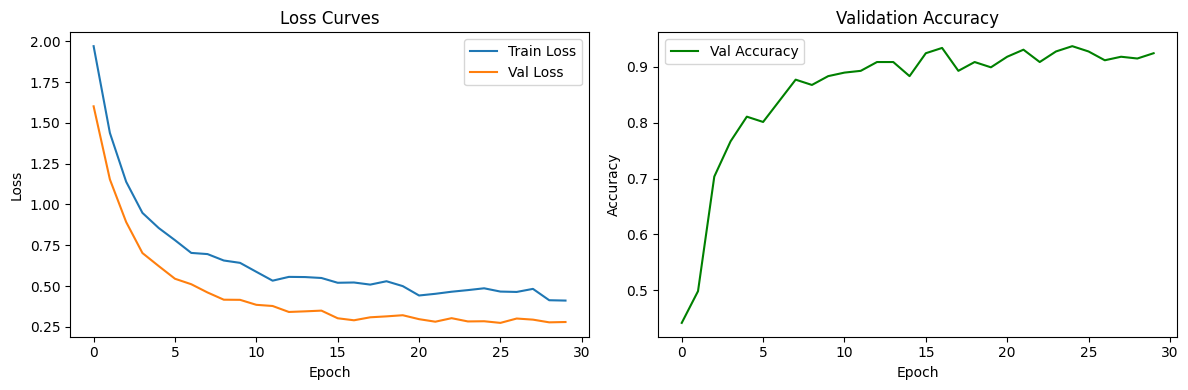

In [19]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss Curves')
axes[1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].set_title('Validation Accuracy')
plt.tight_layout()
plt.show()

## **Evaluation**

In [20]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        _, logits, _ = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = (all_preds == all_labels).mean()
print("Test Accuracy:", test_accuracy)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 0.9148264984227129

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.89      1.00      0.94        41
      Normal_Weight       0.87      0.79      0.83        43
     Obesity_Type_I       0.93      0.98      0.95        53
    Obesity_Type_II       0.98      0.98      0.98        45
   Obesity_Type_III       1.00      0.98      0.99        49
 Overweight_Level_I       0.78      0.88      0.83        43
Overweight_Level_II       0.97      0.77      0.86        43

           accuracy                           0.91       317
          macro avg       0.92      0.91      0.91       317
       weighted avg       0.92      0.91      0.91       317



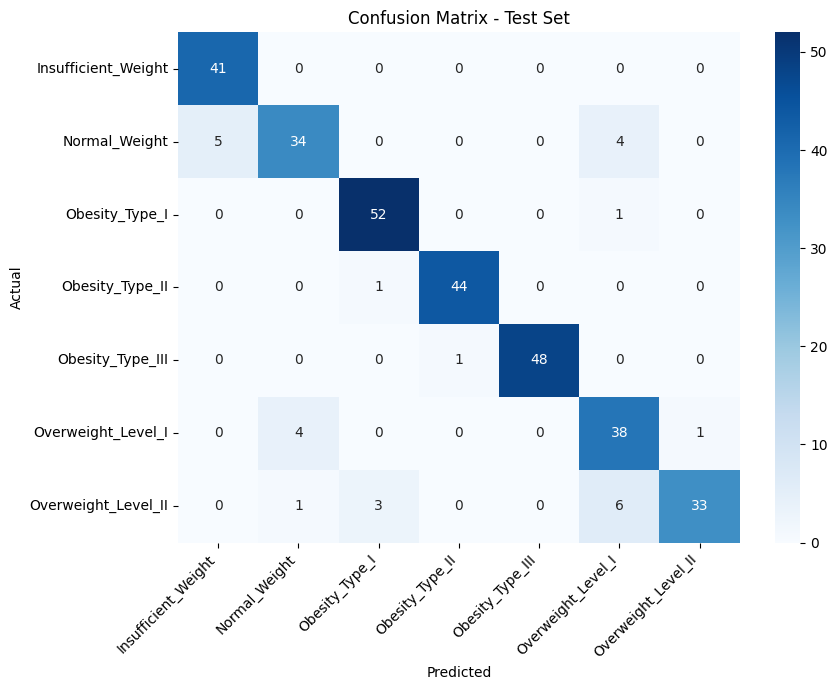

In [21]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Latent Vector and Data Storage**

In [22]:
# Compute latent vectors for the training set. We use a *non-shuffled*
# loader here (train_loader has shuffle=True, which would break the
# row-for-row alignment between Z_train and X_train) so that row i of
# Z_train always corresponds to row i of X_train / y_train.
model.eval()

train_loader_ordered = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_z = []
with torch.no_grad():
    for xb, _ in train_loader_ordered:
        xb = xb.to(device)
        _, _, z = model(xb)
        all_z.append(z.cpu().numpy())

Z_train = np.vstack(all_z)
print(f"Latent vectors (train) shape: {Z_train.shape}")

# Also compute latent vectors for the validation set (val_loader is already
# shuffle=False, so no need for an ordered copy here). Test latents are
# deliberately left out of the searchable pool.
all_z_val = []
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(device)
        _, _, z = model(xb)
        all_z_val.append(z.cpu().numpy())

Z_val = np.vstack(all_z_val)
print(f"Latent vectors (val)   shape: {Z_val.shape}")

Latent vectors (train) shape: (1477, 16)
Latent vectors (val)   shape: (317, 16)


In [23]:
# Persist the latent vectors together with the corresponding cleaned patient
# profiles (row-aligned), so a later kNN lookup can map a latent vector back
# to the original patient data. The searchable "pool" combines train + val
# (test latents are intentionally excluded, since test is held out for
# evaluation only).
train_profiles = X_train.reset_index(drop=True).copy()
train_profiles['target'] = y_train.reset_index(drop=True)
train_profiles['NObeyesdad'] = label_encoder.inverse_transform(train_profiles['target'])
train_profiles['split'] = 'train'

val_profiles = X_val.reset_index(drop=True).copy()
val_profiles['target'] = y_val.reset_index(drop=True)
val_profiles['NObeyesdad'] = label_encoder.inverse_transform(val_profiles['target'])
val_profiles['split'] = 'val'

Z_pool = np.vstack([Z_train, Z_val])
patient_profiles_pool = pd.concat([train_profiles, val_profiles], ignore_index=True)

assert Z_pool.shape[0] == len(patient_profiles_pool)

os.makedirs('artifacts', exist_ok=True)

np.save('artifacts/latent_vectors_pool.npy', Z_pool)
patient_profiles_pool.to_csv('artifacts/latent_patient_profiles_pool.csv', index=False)

print(f"Saved {Z_pool.shape[0]} latent vectors (train+val) -> artifacts/latent_vectors_pool.npy")
print(f"Saved corresponding patient profiles           -> artifacts/latent_patient_profiles_pool.csv")

Saved 1794 latent vectors (train+val) -> artifacts/latent_vectors_pool.npy
Saved corresponding patient profiles           -> artifacts/latent_patient_profiles_pool.csv


## **Artifact Saving**

In [24]:
# Final summary of everything saved during this run
config = {
    'input_dim': input_dim,
    'latent_dim': LATENT_DIM,
    'num_classes': num_classes,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'class_names': list(class_names),
    'test_accuracy': float(test_accuracy),
    'best_val_loss': float(best_val_loss),
}

with open('artifacts/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("All artifacts saved in ./artifacts:")
for fname in sorted(os.listdir('artifacts')):
    print(" -", fname)

All artifacts saved in ./artifacts:
 - best_encoder_decoder_model.pth
 - config.json
 - label_encoder.joblib
 - latent_patient_profiles_pool.csv
 - latent_vectors_pool.npy
 - preprocessing_pipeline.joblib


## **Inference**

In [25]:
# ------------------------------------------------------------------
# Explicitly reload the preprocessing pipeline, label encoder, and trained
# model from disk (instead of relying on the objects already in memory),
# then run inference on a patient profile.
# ------------------------------------------------------------------

# 1. Load artifacts from disk
inf_preprocessor = joblib.load('artifacts/preprocessing_pipeline.joblib')
inf_label_encoder = joblib.load('artifacts/label_encoder.joblib')

checkpoint = torch.load('artifacts/best_encoder_decoder_model.pth', map_location=device)

inf_model = EncoderDecoderClassifier(
    input_dim=checkpoint['input_dim'],
    latent_dim=checkpoint['latent_dim'],
    num_classes=checkpoint['num_classes']
).to(device)
inf_model.load_state_dict(checkpoint['model_state_dict'])
inf_model.eval()

print("Loaded preprocessing pipeline, label encoder, and model from ./artifacts")

# 2. Example: treat one held-out test-set patient as a "new" incoming profile
sample_patient = X_test.iloc[[0]]   # keep as a 1-row DataFrame
true_label = inf_label_encoder.inverse_transform([y_test.iloc[0]])[0]

# 3. Preprocess with the loaded pipeline and run through the loaded model
sample_proc = inf_preprocessor.transform(sample_patient)
sample_t = torch.tensor(sample_proc, dtype=torch.float32).to(device)

with torch.no_grad():
    _, logits, sample_z = inf_model(sample_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())

pred_label = inf_label_encoder.inverse_transform([pred_idx])[0]
sample_latent = sample_z.cpu().numpy()  # reused below for the kNN lookup

print(f"\nTrue label:      {true_label}")
print(f"Predicted label: {pred_label}  (confidence: {probs[pred_idx]:.3f})")

Loaded preprocessing pipeline, label encoder, and model from ./artifacts

True label:      Insufficient_Weight
Predicted label: Insufficient_Weight  (confidence: 0.975)


## **kNN Latent Space**

In [26]:
# ------------------------------------------------------------------
# Explicitly reload the stored latent vectors and their corresponding
# cleaned patient profiles, then run k-NN in latent space to pull out the
# most similar patient profiles to the one predicted above. The searchable
# pool is train + val latents (test is left out).
# ------------------------------------------------------------------


# 1. Load latent vectors + matching patient profiles from disk
knn_Z_pool = np.load('artifacts/latent_vectors_pool.npy')
knn_patient_profiles = pd.read_csv('artifacts/latent_patient_profiles_pool.csv')

print(f"Loaded {knn_Z_pool.shape[0]} latent vectors of dimension {knn_Z_pool.shape[1]}")
print(knn_patient_profiles['split'].value_counts())

# 2. Fit a k-NN index over the latent space
K = 5
knn = NearestNeighbors(n_neighbors=K, metric='euclidean')
knn.fit(knn_Z_pool)

def find_similar_patients(query_latent, k=K):
    """Given a 1 x latent_dim vector, return the k most similar cleaned
    patient profiles from the train+val pool (by Euclidean distance in the
    latent space), closest first."""
    query_latent = np.asarray(query_latent).reshape(1, -1)
    distances, indices = knn.kneighbors(query_latent, n_neighbors=k)
    results = knn_patient_profiles.iloc[indices[0]].copy()
    results.insert(0, 'latent_distance', distances[0])
    return results.reset_index(drop=True)

# 3. Reuse the latent vector computed for the sample patient during inference
similar_patients = find_similar_patients(sample_latent, k=K)

print(f"\nQuery patient predicted as: {pred_label}")
print(f"Top {K} most similar patient profiles (by latent-space distance):")
similar_patients

Loaded 1794 latent vectors of dimension 16
split
train    1477
val       317
Name: count, dtype: int64

Query patient predicted as: Insufficient_Weight
Top 5 most similar patient profiles (by latent-space distance):


,latent_distance,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,target,NObeyesdad,split
0,0.347569,Male,yes,yes,Sometimes,no,no,no,Automobile,18.000000,1.845399,60.000000,3.000000,4.0,2.0,2.0,0.000000,0,Insufficient_Weight,train
1,0.455000,Male,yes,yes,Sometimes,no,no,no,Automobile,17.491272,1.834637,59.990861,2.943749,4.0,2.0,2.0,0.128895,0,Insufficient_Weight,train
2,0.585442,Male,yes,yes,Sometimes,no,no,no,Automobile,17.469417,1.798645,59.612717,2.336044,4.0,2.0,2.0,0.133005,0,Insufficient_Weight,train
3,0.633361,Male,yes,yes,Sometimes,no,no,no,Automobile,17.120699,1.809251,58.968994,2.524428,4.0,2.0,2.0,0.038380,0,Insufficient_Weight,train
4,0.675743,Male,yes,yes,Sometimes,no,no,no,Automobile,17.908114,1.793926,59.682591,2.568063,4.0,2.0,2.0,0.220029,0,Insufficient_Weight,train


## **Constrained kNN Feature Space**

In [27]:
# Explicit clinical/severity ordering of the obesity classes, from most
# underweight to most obese, with Normal_Weight as the "healthy" center.
# Moving one step toward Normal_Weight (in either direction) defines what we
# mean by a "healthier" class for a given predicted class.
SEVERITY_ORDER = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6,
}

# Sanity check: every class the label encoder knows about must be covered.
missing = set(inf_label_encoder.classes_) - set(SEVERITY_ORDER.keys())
if missing:
    raise ValueError(f"SEVERITY_ORDER is missing class(es): {missing}. Update the mapping above.")

def get_healthier_target_class(predicted_class):
    """Return the class name one severity step closer to Normal_Weight than
    `predicted_class`, or None if `predicted_class` is already Normal_Weight."""
    current_rank = SEVERITY_ORDER[predicted_class]
    normal_rank = SEVERITY_ORDER['Normal_Weight']
    if current_rank == normal_rank:
        return None
    step = -1 if current_rank > normal_rank else 1
    target_rank = current_rank + step
    return next(c for c, r in SEVERITY_ORDER.items() if r == target_rank)

target_class = get_healthier_target_class(pred_label)
if target_class is None:
    print(f"Predicted class is already 'Normal_Weight' -- no healthier prototype needed.")
else:
    print(f"Predicted class: {pred_label}  ->  healthier target class: {target_class}")

Predicted class: Insufficient_Weight  ->  healthier target class: Normal_Weight


In [28]:
#from IPython.display import display

# ------------------------------------------------------------------
# Explicitly reload the train+val patient profile pool (test stays
# excluded, consistent with the latent-space kNN above), then run a
# constrained kNN in feature space: same gender, age +-2 years, and
# belonging to the healthier target class.
# ------------------------------------------------------------------
cknn_patient_profiles = pd.read_csv('artifacts/latent_patient_profiles_pool.csv')

K2 = 7
healthier_neighbors = None

if target_class is None:
    print("Query is already Normal_Weight -- skipping constrained kNN.")
else:
    query_gender = sample_patient['Gender'].iloc[0]
    query_age = sample_patient['Age'].iloc[0]

    candidate_mask = (
        (cknn_patient_profiles['Gender'] == query_gender) &
        (cknn_patient_profiles['Age'].between(query_age - 2, query_age + 2)) &
        (cknn_patient_profiles['NObeyesdad'] == target_class)
    )
    candidates = cknn_patient_profiles[candidate_mask].copy()
    print(f"Candidates with Gender={query_gender}, Age in [{query_age-2}, {query_age+2}], "
          f"class={target_class}: {len(candidates)}")

    if len(candidates) == 0:
        print("No candidates satisfy the constraints -- try relaxing the age window or gender filter.")
    else:
        # Distance is computed in feature space, using the same fitted
        # preprocessing pipeline the model was trained on.
        candidate_features_proc = inf_preprocessor.transform(candidates[feature_cols])
        dists = np.linalg.norm(candidate_features_proc - sample_proc, axis=1)

        k_use = min(K2, len(candidates))
        nearest_idx = np.argsort(dists)[:k_use]

        healthier_neighbors = candidates.iloc[nearest_idx].copy()
        healthier_neighbors.insert(0, 'feature_distance', dists[nearest_idx])
        healthier_neighbors = healthier_neighbors.reset_index(drop=True)

        print(f"\nTop {k_use} nearest '{target_class}' neighbors (same gender, age +-2) "
              f"-- the healthier prototype:")
        display(healthier_neighbors)

Candidates with Gender=Male, Age in [15.925497, 19.925497], class=Normal_Weight: 45

Top 7 nearest 'Normal_Weight' neighbors (same gender, age +-2) -- the healthier prototype:


,feature_distance,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,target,NObeyesdad,split
0,2.816095,Male,yes,yes,Sometimes,no,no,Sometimes,Automobile,18.0,1.80,72.0,2.0,3.0,2.0,3.0,0.0,1,Normal_Weight,train
1,2.907852,Male,yes,yes,Frequently,no,no,Sometimes,Public_Transportation,19.0,1.83,82.0,3.0,3.0,2.0,2.0,0.0,1,Normal_Weight,train
2,3.003164,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,18.0,1.70,55.3,3.0,3.0,2.0,3.0,0.0,1,Normal_Weight,train
3,3.006647,Male,no,yes,Sometimes,no,no,no,Public_Transportation,18.0,1.75,70.0,3.0,4.0,2.0,1.0,1.0,1,Normal_Weight,train
4,3.109819,Male,yes,yes,Sometimes,no,yes,Sometimes,Public_Transportation,18.0,1.74,64.0,3.0,4.0,1.0,2.0,0.0,1,Normal_Weight,train
5,3.152082,Male,yes,yes,Sometimes,no,no,no,Public_Transportation,17.0,1.74,56.0,2.0,3.0,2.0,2.0,1.0,1,Normal_Weight,val
6,3.167478,Male,yes,yes,Frequently,no,no,Sometimes,Automobile,18.0,1.76,70.0,2.0,4.0,2.0,2.0,1.0,1,Normal_Weight,train


In [29]:
# ------------------------------------------------------------------
# Critic: compare the query patient against the healthier-prototype
# centroid (mean of the 7 constrained neighbors) and report which
# *original* features (not one-hot dummies) would need to shift most to
# move the query closer to that healthier outcome.
#
# Some features aren't actionable -- a patient can't change their Age,
# Height, Gender, or family history on purpose -- so even if the prototype
# centroid differs slightly on these (e.g. Age drifting within the +-2
# window, or rounding noise), they shouldn't be surfaced as "recommended
# changes". We exclude them from the table below.
# ------------------------------------------------------------------
NON_ACTIONABLE_FEATURES = ['Age', 'Height', 'Gender', 'family_history_with_overweight']

if healthier_neighbors is None or len(healthier_neighbors) == 0:
    print("No healthier prototype available -- skipping critic analysis.")
else:
    neighbor_features_proc = inf_preprocessor.transform(healthier_neighbors[feature_cols])
    prototype_centroid_proc = neighbor_features_proc.mean(axis=0, keepdims=True)

    delta_proc = (prototype_centroid_proc - sample_proc).flatten()

    feature_names = inf_preprocessor.get_feature_names_out()
    n_numeric = len(numerical_cols)

    # Inverse-transform the numeric block back to original units for readability
    num_scaler = inf_preprocessor.named_transformers_['num'].named_steps['scaler']
    sample_num_orig = num_scaler.inverse_transform(sample_proc[:, :n_numeric])[0]
    centroid_num_orig = num_scaler.inverse_transform(prototype_centroid_proc[:, :n_numeric])[0]

    critic_rows = []

    # --- Numeric features: one row each, values in original units ---
    for i, col in enumerate(numerical_cols):
        if col in NON_ACTIONABLE_FEATURES:
            continue
        critic_rows.append({
            'feature': col,
            'current_value': round(float(sample_num_orig[i]), 2),
            'prototype_value': round(float(centroid_num_orig[i]), 2),
            'shift_magnitude': round(abs(float(delta_proc[i])), 3),
        })

    # --- Categorical features: collapse each one-hot block back into a
    # single row, comparing the query's actual category against the most
    # common category among the healthier-prototype neighbors ---
    cat_feature_names = feature_names[n_numeric:]
    for col in categorical_cols:
        if col in NON_ACTIONABLE_FEATURES:
            continue
        col_idx_local = [i for i, fname in enumerate(cat_feature_names) if fname.startswith(f'cat__{col}_')]
        col_idx_full = [n_numeric + i for i in col_idx_local]

        current_category = sample_patient[col].iloc[0]

        mode_counts = healthier_neighbors[col].value_counts(normalize=True)
        prototype_category = mode_counts.index[0]
        prototype_share = mode_counts.iloc[0]

        shift_magnitude = float(np.linalg.norm(delta_proc[col_idx_full]))

        critic_rows.append({
            'feature': col,
            'current_value': current_category,
            'prototype_value': f"{prototype_category} ({prototype_share:.0%} of neighbors)",
            'shift_magnitude': round(shift_magnitude, 3),
        })

    critic_df = pd.DataFrame(critic_rows)
    critic_df = critic_df.sort_values('shift_magnitude', ascending=False).reset_index(drop=True)

    TOP_N = 8
    print(f"Excluded non-actionable features from recommendations: {NON_ACTIONABLE_FEATURES}\n")
    print(f"Query predicted as '{pred_label}'. Actionable features ranked by how much they'd need "
          f"to shift to look like the '{target_class}' healthier prototype (top {TOP_N} by magnitude):\n")
    display(critic_df.head(TOP_N))

Excluded non-actionable features from recommendations: ['Age', 'Height', 'Gender', 'family_history_with_overweight']

Query predicted as 'Insufficient_Weight'. Actionable features ranked by how much they'd need to shift to look like the 'Normal_Weight' healthier prototype (top 8 by magnitude):



,feature,current_value,prototype_value,shift_magnitude
0,MTRANS,Automobile,Public_Transportation (71% of neighbors),1.010
1,CALC,no,Sometimes (71% of neighbors),1.010
2,NCP,4.0,3.43,0.733
3,TUE,0.01,0.43,0.702
4,FCVC,2.86,2.57,0.542
5,CAEC,Sometimes,Sometimes (71% of neighbors),0.404
6,Weight,59.93,67.04,0.272
7,CH2O,2.0,1.86,0.234
